Частина ознак має сильний зв’язок із ціною, інші майже не дають інформації для прогнозу. Методи типу взаємної інформації та RandomForest добре допомагають відсіяти зайве й зрозуміти структуру даних. Загалом, щоб якісно оцінити важливість ознак, краще використовувати кілька підходів одразу тоді картина виходить більш об’єктивною.

Index(['make', 'fuel_type', 'aspiration', 'body_style', 'drive_wheels',
       'engine_location', 'engine_type', 'fuel_system'],
      dtype='object')
curb_weight          0.912535
engine_size          0.908112
horsepower           0.884634
highway_mpg          0.879198
city_mpg             0.781008
width                0.674535
length               0.608787
wheel_base           0.592981
make                 0.544057
bore                 0.500620
fuel_system          0.479850
stroke_ratio         0.418750
stroke               0.384427
height               0.354141
drive_wheels         0.332490
num_of_cylinders     0.332440
peak_rpm             0.230581
engine_type          0.150524
compression_ratio    0.100102
aspiration           0.087994
body_style           0.081785
fuel_type            0.048139
engine_location      0.036336
num_of_doors         0.012705
dtype: float64
engine_size          0.651372
curb_weight          0.215493
highway_mpg          0.029576
horsepower           0.0

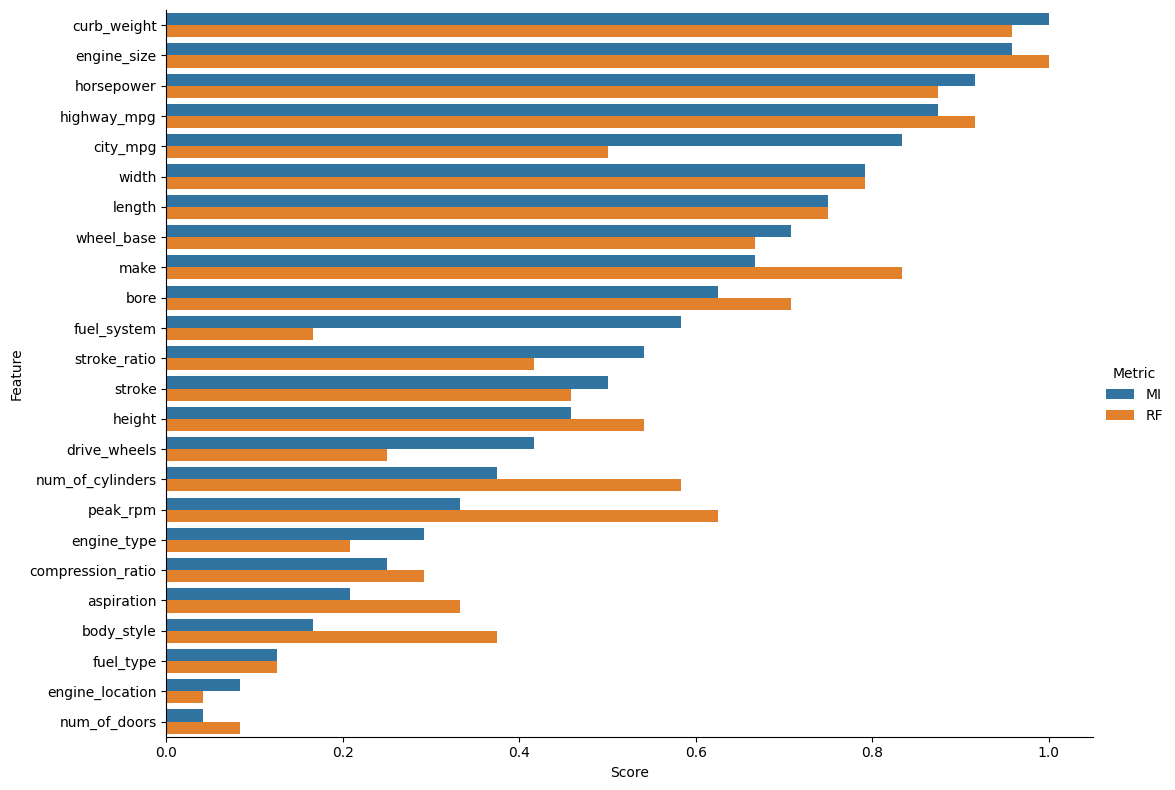

In [2]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder 
import urllib.request

#завантаження даних
url = 'https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl'
with urllib.request.urlopen(url) as response:
    datasets = pickle.load(response)
    
autos = datasets['autos']
autos['stroke_ratio'] = autos['stroke'] / autos['bore']
autos[['stroke', 'bore', 'stroke_ratio']].head()

#визначення ознак
y = autos['price']
x = autos.drop('price', axis=1)

catеgory_col = x.select_dtypes(include='object').columns
print(catеgory_col)

#розрахунок показника взаємної інформації для вхідних ознак
x_mi = x.copy()
x_mi[catеgory_col] = x_mi[catеgory_col].apply(lambda col: col.factorize()[0])
discrete_features = [True if col in catеgory_col else False for col in x.columns]
mi_scores = pd.Series(mutual_info_regression(x_mi, y, discrete_features= discrete_features, random_state= 42), index=x.columns).sort_values(ascending= False)

print(mi_scores)

#побудова Random Forest
encoder = OrdinalEncoder(handle_unknown= 'use_encoded_value', unknown_value= -1)

x_encoder = x.copy()
x_encoder[catеgory_col] = encoder.fit_transform(x_encoder[catеgory_col])
model = RandomForestRegressor(n_estimators= 300, random_state= 42)
model.fit(x_encoder, y)
fi = pd.Series(model.feature_importances_, index= x.columns).sort_values(ascending= False)

print(fi)

#важливість ознак у моделі за допомогою методу .rank(pct=True)
scores = pd.concat([mi_scores, fi], axis=1)
scores.columns = ['MI', 'RF']
scores = scores.rank(pct=True)

print(scores.sort_values('RF', ascending=False))

#візуалізація
plot_data = scores.reset_index().melt(id_vars= 'index')
plot_data.columns = ['Feature', 'Metric', 'Score']

sns.catplot(
    data= plot_data,
    kind= 'bar',
    x= 'Score',
    y= 'Feature',
    hue= 'Metric',
    height= 8,
    aspect= 1.4)
plt.show()